# Putting a number on "but what about confounding?": E-value computation in Python

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aflaxman/ai_assisted_research/blob/main/evalue_examples/tutorial.ipynb)

Companion notebook to a [healthyalgorithms.com](https://healthyalgorithms.com) post.
It is **self-contained**: everything runs from scratch, downloading ~25 MB of
public data from the CDC (NHANES exam files and the NCHS public-use linked
mortality files). Two examples:

1. **Acetaminophen in pregnancy and autism** — replicating the E-values in
   Andrade's tutorial ([J Clin Psychiatry 2026;87(1):26f16324](https://www.psychiatrist.com/jcp/e-value-regression-useful-easily-understood-easily-applied-statistic/))
   from the open-access source study (Ahlqvist et al.,
   [JAMA 2024;331(14):1205-1214](https://pmc.ncbi.nlm.nih.gov/articles/PMC11004836/)).
2. **Systolic blood pressure and heart-disease death** — an example where the
   confounder (age) is measured, so we can watch the E-value logic work,
   using NHANES 2003-2010 linked to mortality through 2019.

## Part 0: The E-value in a few lines of Python

The E-value (VanderWeele & Ding, *Ann Intern Med* 2017) is the minimum
strength of association, on the risk-ratio scale, that an unmeasured
confounder would need with **both** the exposure and the outcome to fully
explain away an observed association:

$$E = RR + \sqrt{RR\,(RR - 1)}$$

Hazard ratios, and odds ratios when the outcome is uncommon (<15%), can be
treated as risk ratios here. Protective estimates (RR < 1) get inverted
first. For a confidence interval, compute the E-value of the bound closer
to the null (and if the interval crosses 1, no confounding is needed at
all, so the E-value is 1).

In [1]:
import math


def evalue(rr):
    """E-value for a risk ratio point estimate."""
    if rr <= 0:
        raise ValueError("risk ratio must be positive")
    if rr < 1:
        rr = 1 / rr
    return rr + math.sqrt(rr * (rr - 1))


def evalue_ci(estimate, lo, hi):
    """E-value for the CI limit closer to the null (1.0 if the CI crosses 1)."""
    if lo <= 1 <= hi:
        return 1.0
    return evalue(lo if estimate >= 1 else hi)


def bias_factor(rr_eu, rr_ud):
    """Ding & VanderWeele bounding factor for a confounder of known strength."""
    return rr_eu * rr_ud / (rr_eu + rr_ud - 1)


# Sanity checks against published values:
print(f"evalue(1.05) = {evalue(1.05):.2f}   (Andrade 2026 reports 1.28)")
print(f"evalue(3.90) = {evalue(3.90):.2f}   (VanderWeele & Ding 2017 report 7.26)")
print(f"evalue(0.50) = {evalue(0.50):.2f}   (Andrade 2026 reports 3.41)")

evalue(1.05) = 1.28   (Andrade 2026 reports 1.28)
evalue(3.90) = 7.26   (VanderWeele & Ding 2017 report 7.26)
evalue(0.50) = 3.41   (Andrade 2026 reports 3.41)


## Part 1: Acetaminophen in pregnancy and autism

Ahlqvist et al. (JAMA 2024) followed 2,480,797 children born in Sweden
1995-2019; 185,909 (7.49%) had gestational acetaminophen exposure. The
individual-level register data cannot leave Sweden -- but E-values need only
the published estimates, so the tutorial's calculation is fully reproducible
from the open-access paper:

| Analysis | Estimate (95% CI) |
|---|---|
| Full cohort, adjusted | HR 1.05 (1.02-1.08) |
| Crude 10-yr cumulative incidence | 1.53% exposed vs 1.33% unexposed |
| Sibling control | HR 0.98 (0.93-1.04) |

In [2]:
# Published estimates (Ahlqvist et al. JAMA 2024, open access PMC11004836)
full_cohort = dict(hr=1.05, lo=1.02, hi=1.08)
sibling = dict(hr=0.98, lo=0.93, hi=1.04)
cum_inc = dict(exposed=0.0153, unexposed=0.0133)  # 10-yr cumulative incidence

e_point = evalue(full_cohort["hr"])
e_ci = evalue_ci(full_cohort["hr"], full_cohort["lo"], full_cohort["hi"])
print(f"Full cohort adjusted HR {full_cohort['hr']}: "
      f"E-value {e_point:.2f} (point), {e_ci:.2f} (CI bound)")
assert (round(e_point, 2), round(e_ci, 2)) == (1.28, 1.16)  # matches Andrade 2026

rr_crude = cum_inc["exposed"] / cum_inc["unexposed"]
print(f"Crude RR {rr_crude:.2f}: E-value {evalue(rr_crude):.2f}")

print(f"Sibling-control HR {sibling['hr']}: "
      f"E-value {evalue(sibling['hr']):.2f} (point), "
      f"{evalue_ci(sibling['hr'], sibling['lo'], sibling['hi']):.2f} (CI bound)")

Full cohort adjusted HR 1.05: E-value 1.28 (point), 1.16 (CI bound)
Crude RR 1.15: E-value 1.57
Sibling-control HR 0.98: E-value 1.16 (point), 1.00 (CI bound)


The tutorial stops at the first row. The paper's **sibling-control
analysis** -- comparing exposed and unexposed children of the same mother,
which absorbs shared familial confounding -- took the association to the
null (HR 0.98). A confounder of exactly the modest strength the E-value
flagged (1.28) really existed, and a design that removes it removed the
association.

### The algebra: from bounding factor to E-value

Ding & VanderWeele (*Epidemiology* 2016) proved, with no assumptions about
the confounder's form: if an unmeasured confounder $U$ is more prevalent
among the exposed by a ratio $RR_{EU}$, and is associated with the outcome
by $RR_{UD}$, then confounding by $U$ can inflate an observed risk ratio by
at most the bounding factor

$$B = \frac{RR_{EU} \times RR_{UD}}{RR_{EU} + RR_{UD} - 1},$$

so the true effect satisfies $RR_{true} \ge RR_{obs} / B$. Explaining an
association away entirely requires $B \ge RR_{obs}$.

The E-value asks: what if the confounder is equally strong on both sides,
$RR_{EU} = RR_{UD} = E$? Set $B = RR_{obs}$ and solve:

$$\frac{E^2}{2E - 1} = RR_{obs}
\;\Longrightarrow\;
E^2 - 2\,RR_{obs}\,E + RR_{obs} = 0
\;\Longrightarrow\;
E = RR_{obs} + \sqrt{RR_{obs}\,(RR_{obs} - 1)},$$

taking the positive root of the quadratic. The E-value is just the
equal-strength solution of the bounding factor -- check:

In [3]:
for rr in (1.05, 1.5, 3.9):
    e = evalue(rr)
    print(f"RR {rr}: E-value {e:.4f}, bias_factor(E, E) = {bias_factor(e, e):.4f}")

RR 1.05: E-value 1.2791, bias_factor(E, E) = 1.0500
RR 1.5: E-value 2.3660, bias_factor(E, E) = 1.5000
RR 3.9: E-value 7.2630, bias_factor(E, E) = 3.9000


## Part 2: SBP and heart-disease death -- watching the E-value logic work

Age raises systolic blood pressure, and separately raises heart-disease
risk more than almost anything else does -- a classic confounder. Unlike the
Swedish registers, this data is genuinely open: NHANES 2003-2010 blood
pressure exams linked to the
[NCHS public-use mortality files](https://www.cdc.gov/nchs/data-linkage/mortality-public.htm)
(follow-up through Dec 31, 2019).

- **Exposure:** mean measured SBP >= 140 mm Hg
- **Outcome:** death from diseases of heart (`UCOD_LEADING = 1`, the closest
  public proxy for IHD incidence) within 105 months -- a window fully
  observed for every cycle
- **Weights:** NHANES is a complex survey, so every estimate below uses the
  MEC exam weights (`WTMEC2YR / 4` for four combined cycles). Point
  estimates only; design-based CIs would additionally need the survey
  design variables via Taylor linearization.

The game: **pretend age is unmeasured**, and see what the E-value machinery
says before we "discover" age and adjust for it.

In [4]:
import urllib.request
from pathlib import Path

import pandas as pd

DATA = Path("nhanes_data")
DATA.mkdir(exist_ok=True)
CYCLES = {"2003_2004": ("2003", "C"), "2005_2006": ("2005", "D"),
          "2007_2008": ("2007", "E"), "2009_2010": ("2009", "F")}
XPT_BASE = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public"
LMF_BASE = ("https://ftp.cdc.gov/pub/Health_Statistics/NCHS/"
            "datalinkage/linked_mortality")


def fetch(url, dest):
    if not dest.exists():
        print(f"downloading {url}")
        urllib.request.urlretrieve(url, dest)
    return dest


for cycle, (year, sfx) in CYCLES.items():
    for prefix in ("DEMO", "BPX"):
        fetch(f"{XPT_BASE}/{year}/DataFiles/{prefix}_{sfx}.xpt",
              DATA / f"{prefix}_{sfx}.xpt")
    fetch(f"{LMF_BASE}/NHANES_{cycle}_MORT_2019_PUBLIC.dat",
          DATA / f"NHANES_{cycle}_MORT_2019_PUBLIC.dat")
print("all files present")

downloading https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2003/DataFiles/DEMO_C.xpt


downloading https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2003/DataFiles/BPX_C.xpt


downloading https://ftp.cdc.gov/pub/Health_Statistics/NCHS/datalinkage/linked_mortality/NHANES_2003_2004_MORT_2019_PUBLIC.dat


downloading https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/DEMO_D.xpt


downloading https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/BPX_D.xpt


...

downloading https://ftp.cdc.gov/pub/Health_Statistics/NCHS/datalinkage/linked_mortality/NHANES_2007_2008_MORT_2019_PUBLIC.dat


downloading https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/DEMO_F.xpt


downloading https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/BPX_F.xpt


downloading https://ftp.cdc.gov/pub/Health_Statistics/NCHS/datalinkage/linked_mortality/NHANES_2009_2010_MORT_2019_PUBLIC.dat


all files present


In [5]:
def parse_lmf(path):
    """Parse an NCHS public-use linked mortality fixed-width file."""
    rows = []
    with open(path) as f:
        for line in f:
            p = line.rstrip("\r\n").ljust(48)

            def safe(s, to_type=int):
                s = s.strip().replace(".", "")
                return to_type(s) if s else None

            rows.append({"SEQN": safe(p[0:14]), "ELIGSTAT": safe(p[14:15]),
                         "MORTSTAT": safe(p[15:16]),
                         "UCOD_LEADING": safe(p[16:19]),
                         "PERMTH_EXM": safe(p[45:48], float)})
    return pd.DataFrame(rows)


WINDOW = 105  # months of follow-up, fully observed for every cycle
parts = []
for cycle, (year, sfx) in CYCLES.items():
    demo = pd.read_sas(DATA / f"DEMO_{sfx}.xpt", format="xport")
    bpx = pd.read_sas(DATA / f"BPX_{sfx}.xpt", format="xport")
    part = demo[["SEQN", "RIDAGEYR", "WTMEC2YR"]].merge(
        bpx[["SEQN", "BPXSY1", "BPXSY2", "BPXSY3", "BPXSY4"]], on="SEQN")
    parts.append(part.merge(parse_lmf(DATA / f"NHANES_{cycle}_MORT_2019_PUBLIC.dat"),
                            on="SEQN"))
df = pd.concat(parts, ignore_index=True)

df["SBP"] = df[["BPXSY1", "BPXSY2", "BPXSY3", "BPXSY4"]].mean(axis=1)
df = df[(df.RIDAGEYR >= 20) & df.SBP.notna() & (df.WTMEC2YR > 0)
        & (df.ELIGSTAT == 1) & df.MORTSTAT.isin([0, 1])].copy()
df["W"] = df.WTMEC2YR / len(CYCLES)
df["exposed"] = df.SBP >= 140
df["heart_death"] = ((df.MORTSTAT == 1) & (df.UCOD_LEADING == 1)
                     & (df.PERMTH_EXM <= WINDOW))
df["old"] = df.RIDAGEYR >= 60

assert df.loc[df.MORTSTAT == 0, "PERMTH_EXM"].min() >= WINDOW
print(f"adults 20+ with SBP and mortality linkage: {len(df):,}")
print(f"heart-disease deaths within {WINDOW} months: {int(df.heart_death.sum()):,}")

adults 20+ with SBP and mortality linkage: 20,109
heart-disease deaths within 105 months: 664


In [6]:
def wrisk(d):
    """Weighted cumulative risk of heart-disease death in the window."""
    return (d.W * d.heart_death).sum() / d.W.sum()


exp, unexp = df[df.exposed], df[~df.exposed]

# 1. The crude association and its E-value
r1, r0 = wrisk(exp), wrisk(unexp)
rr_crude = r1 / r0
print(f"crude risk: {r1:.2%} (SBP>=140) vs {r0:.2%} (SBP<140)")
print(f"crude RR {rr_crude:.2f}, E-value {evalue(rr_crude):.2f}")

# 2. Age's actual strength as a confounder
p_old = lambda d: (d.W * d.old).sum() / d.W.sum()
rr_eu = p_old(exp) / p_old(unexp)
rr_ud = max(wrisk(g[g.old]) / wrisk(g[~g.old]) for g in (exp, unexp))
print(f"\nage 60+ prevalence: {p_old(exp):.1%} exposed vs {p_old(unexp):.1%} "
      f"unexposed -> RR_EU = {rr_eu:.2f}")
print(f"heart-death risk 60+ vs <60 -> RR_UD = {rr_ud:.2f}")

# 3. What the bounding factor predicts age can do
b = bias_factor(rr_eu, rr_ud)
print(f"\nbounding factor B = {b:.2f} "
      f"({'>=' if b >= rr_crude else '<'} crude RR {rr_crude:.2f}, so age "
      f"{'could' if b >= rr_crude else 'CANNOT'} fully explain it away)")
print(f"age could shrink the crude RR to at most {rr_crude / b:.2f}")

crude risk: 6.28% (SBP>=140) vs 1.49% (SBP<140)
crude RR 4.20, E-value 7.88

age 60+ prevalence: 56.5% exposed vs 18.0% unexposed -> RR_EU = 3.14
heart-death risk 60+ vs <60 -> RR_UD = 13.59

bounding factor B = 2.72 (< crude RR 4.20, so age CANNOT fully explain it away)
age could shrink the crude RR to at most 1.55


In [7]:
# 4. Now "discover" age and adjust for it: direct standardization
STRATA = [(20, 39), (40, 59), (60, 74), (75, 200)]
rows, std_r1, std_r0 = [], 0.0, 0.0
for lo, hi in STRATA:
    s = df[(df.RIDAGEYR >= lo) & (df.RIDAGEYR <= hi)]
    s1, s0 = s[s.exposed], s[~s.exposed]
    risk1, risk0 = wrisk(s1), wrisk(s0)
    share = s.W.sum() / df.W.sum()
    std_r1 += share * risk1
    std_r0 += share * risk0
    deaths = int(s1.heart_death.sum()), int(s0.heart_death.sum())
    label = f"{lo}-{hi}" if hi < 150 else f"{lo}+"
    rows.append(dict(stratum=label, risk1=risk1, risk0=risk0,
                     rr=risk1 / risk0, small=min(deaths) < 30))
    flag = " *small cell*" if min(deaths) < 30 else ""
    print(f"age {label:>6}: {risk1:6.2%} vs {risk0:6.2%}  "
          f"RR {risk1 / risk0:.2f}  (deaths {deaths[0]}/{deaths[1]}){flag}")

rr_std = std_r1 / std_r0
print(f"\nage-standardized RR {rr_std:.2f}, E-value {evalue(rr_std):.2f}")
print(f"(the bound predicted a floor of {rr_crude / b:.2f})")

age  20-39:  0.46% vs  0.15%  RR 3.17  (deaths 1/10) *small cell*
age  40-59:  1.89% vs  0.79%  RR 2.38  (deaths 24/49) *small cell*
age  60-74:  3.59% vs  3.41%  RR 1.05  (deaths 64/110)
age    75+: 19.16% vs 13.68%  RR 1.40  (deaths 209/197)

age-standardized RR 1.51, E-value 2.38
(the bound predicted a floor of 1.55)


Age accounts for most -- but not all -- of the crude association. The
standardized estimate lands almost exactly where the bounding factor said
it could go, and it can dip slightly under that "floor" because the bound
used age dichotomized at 60, which understates age's full four-stratum
strength.

The contrast with Part 1 is the lesson: an E-value of 1.28 fell to a
modest familial confounder, while explaining away a crude RR of 4.2 would
take a confounder far stronger than age -- about the strongest confounder
epidemiology has. *Confounded* is not the same as *explained away*.

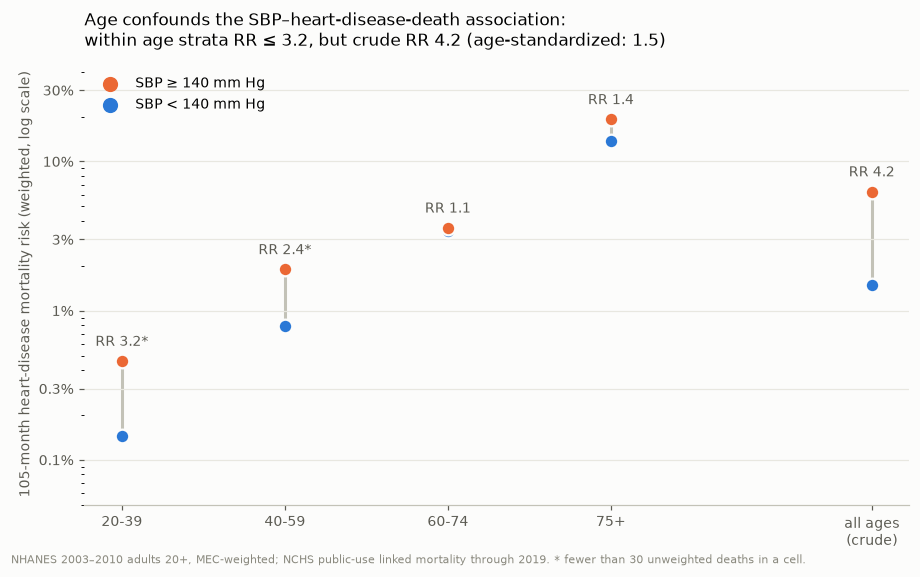

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.4, 5.2), dpi=110)
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")

BLUE, ORANGE = "#2a78d6", "#eb6834"
labels = [r["stratum"] for r in rows] + ["all ages\n(crude)"]
pairs = [(r["risk0"], r["risk1"]) for r in rows] + [(r0, r1)]
notes = [f"RR {r['rr']:.1f}{'*' if r['small'] else ''}" for r in rows]
notes.append(f"RR {rr_crude:.1f}")
xs = list(range(len(rows))) + [len(rows) + 0.6]

dot = dict(s=80, zorder=2, edgecolor="#fcfcfb", linewidth=1.5)
for x, (lo, hi), note in zip(xs, pairs, notes):
    ax.plot([x, x], [lo * 100, hi * 100], color="#c3c2b7", lw=2, zorder=1)
    ax.scatter([x], [lo * 100], color=BLUE, **dot)
    ax.scatter([x], [hi * 100], color=ORANGE, **dot)
    ax.annotate(note, (x, max(lo, hi) * 100), xytext=(0, 10),
                textcoords="offset points", ha="center",
                fontsize=9, color="#5c5b53")

ax.set_yscale("log")
ax.set_yticks([0.1, 0.3, 1, 3, 10, 30])
ax.set_yticklabels(["0.1%", "0.3%", "1%", "3%", "10%", "30%"])
ax.set_ylim(0.05, 45)
ax.set_xticks(xs)
ax.set_xticklabels(labels)
ax.set_ylabel(f"{WINDOW}-month heart-disease mortality risk "
              "(weighted, log scale)", fontsize=9, color="#5c5b53")
ax.tick_params(colors="#5c5b53", labelsize=9)
ax.grid(axis="y", color="#e8e7e0", lw=0.8, zorder=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.scatter([], [], s=80, color=ORANGE, label="SBP ≥ 140 mm Hg")
ax.scatter([], [], s=80, color=BLUE, label="SBP < 140 mm Hg")
ax.legend(loc="upper left", frameon=False, fontsize=9)
ax.set_title(
    "Age confounds the SBP–heart-disease-death association:\n"
    f"within age strata RR ≤ {max(r['rr'] for r in rows):.1f}, "
    f"but crude RR {rr_crude:.1f} (age-standardized: {rr_std:.1f})",
    fontsize=11, loc="left", pad=12)
fig.text(0.01, 0.005,
         "NHANES 2003–2010 adults 20+, MEC-weighted; NCHS public-use linked "
         "mortality through 2019. * fewer than 30 unweighted deaths in a cell.",
         fontsize=7.5, color="#8a897e")
fig.tight_layout()
plt.show()

## Challenges

1. Compute E-values for the last observational paper you refereed.
2. Rerun Part 2 with smoking or BMI as the pretend-unmeasured confounder.
   How close does the bound come to the adjusted estimate then?
3. Verify algebraically that E solves `bias_factor(E, E) = RR`, then break
   the symmetry: for the SBP example, how large would `RR_EU` need to be to
   explain the crude RR away given the observed `RR_UD` of 13.6?
4. Find another exposure with both a full-cohort and a sibling-control
   estimate. Does the E-value predict which associations survive?

## References

- Andrade C. The E-value in regressions. *J Clin Psychiatry*. 2026;87(1):26f16324.
- VanderWeele TJ, Ding P. Sensitivity analysis in observational research:
  introducing the E-value. *Ann Intern Med*. 2017;167(4):268-274.
- Ding P, VanderWeele TJ. Sensitivity analysis without assumptions.
  *Epidemiology*. 2016;27(3):368-377.
- Ahlqvist VH, et al. Acetaminophen use during pregnancy and children's risk
  of autism, ADHD, and intellectual disability. *JAMA*. 2024;331(14):1205-1214.
- E-value calculator: https://www.evalue-calculator.com/